# Notebook 02: Feature Engineering

## Objective
Walk through every stage of the feature engineering pipeline in the `hotel_ranker` package. We will build **raw features**, **match features**, **historical features**, and then run the full **feature pipeline** that combines them all.

The pipeline produces three categories of features covering ~40 columns total.

## Why Feature Engineering Matters for LTR
In Learning-to-Rank, the raw dataset columns (price, star rating, location score) are absolute values. But ranking is inherently **relative**: a $150/night hotel is cheap in Manhattan but expensive in rural Thailand. Feature engineering transforms absolute values into contextual, relative signals that help the model learn what makes an item relevant *within its query context*.

Our feature pipeline produces three categories:

| Category | Description | Examples |
|----------|-------------|----------|
| **Raw** | Direct columns + simple transforms | price_log, price_per_night, star_review_ratio |
| **Match** | Query-item interactions (relative to other items in the same search) | price_diff_from_query_mean, star_match_visitor_pref |
| **Historical** | Past performance aggregates (CTR, booking rate) with Bayesian smoothing | prop_click_rate, dest_booking_rate |

In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load and Preprocess Data

We start by loading the raw CSV, handling missing values, and adding basic derived columns (price_log, price_rank_in_query). Then we split into train/val/test at the **query level** to prevent data leakage.

In [2]:
from hotel_ranker.data.acquisition import find_csv
from hotel_ranker.data.preprocessing import preprocess
from hotel_ranker.data.splitting import query_level_split

# Load and preprocess
csv_path = find_csv()
df = preprocess(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (9917530, 56)
Columns: ['srch_id', 'date_time', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv', 'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv', 'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv

In [3]:
# Query-level split
train_df, val_df, test_df = query_level_split(df)

print(f"Train: {train_df.shape[0]:,} rows ({train_df['srch_id'].nunique():,} queries)")
print(f"Val:   {val_df.shape[0]:,} rows ({val_df['srch_id'].nunique():,} queries)")
print(f"Test:  {test_df.shape[0]:,} rows ({test_df['srch_id'].nunique():,} queries)")

Train: 6,941,198 rows (279,540 queries)
Val:   1,487,064 rows (59,901 queries)
Test:  1,489,268 rows (59,903 queries)


## 2. Raw Features

Raw features are per-row transformations that do not require any cross-row aggregation. They include:

- **Passthrough columns**: star rating, review score, location scores, price, promotion flag, search context (length of stay, booking window, adults, children, rooms).
- **price_per_night**: `price_usd / length_of_stay` -- normalises for trip duration.
- **total_guests**: `adults + children` -- total party size.
- **star_review_ratio**: `star_rating / review_score` -- quality consistency signal (a 5-star hotel with a 2.0 review score is suspicious).
- **price_vs_visitor_hist**: `price_usd / visitor_hist_adr_usd` -- how does this hotel's price compare to what the user typically pays?
- **price_log**: `log1p(price_usd)` -- reduces skewness.
- **price_rank_in_query**: within-query rank of price (1 = cheapest).

In [4]:
from hotel_ranker.features.raw_features import build_raw_features

raw_feats = build_raw_features(train_df)

print(f"Raw features: {raw_feats.shape[1]} columns")
print(f"Columns: {list(raw_feats.columns)}")
raw_feats.head()

Raw features: 22 columns
Columns: ['prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'price_per_night', 'total_guests', 'star_review_ratio', 'price_vs_visitor_hist', 'price_log', 'price_rank_in_query']


,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,price_usd,promotion_flag,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,visitor_hist_starrating,visitor_hist_adr_usd,price_per_night,total_guests,star_review_ratio,price_vs_visitor_hist,price_log,price_rank_in_query
0,3,3.5000,1,2.8300,0.0438,4.9500,104.7700,0,1,0,4,0,1,1,-1.0000,-1.0000,104.7700,4,0.8571,0.0000,4.6613,5.0000
1,4,4.0000,1,2.2000,0.0149,5.0300,170.7400,0,1,0,4,0,1,1,-1.0000,-1.0000,170.7400,4,1.0000,0.0000,5.1460,19.0000
2,3,4.5000,1,2.2000,0.0245,4.9200,179.8000,0,1,0,4,0,1,1,-1.0000,-1.0000,179.8000,4,0.6667,0.0000,5.1974,20.0000
3,2,4.0000,1,2.8300,0.0125,4.3900,602.7700,0,1,0,4,0,1,1,-1.0000,-1.0000,602.7700,4,0.5000,0.0000,6.4032,28.0000
4,4,3.5000,1,2.6400,0.1241,4.9300,143.5800,0,1,0,4,0,1,1,-1.0000,-1.0000,143.5800,4,1.1429,0.0000,4.9738,16.0000


In [5]:
# Summary statistics of raw features
raw_feats.describe().T

,count,mean,std,min,25%,50%,75%,max
prop_starrating,6941198.0000,3.1815,1.0508,0.0000,3.0000,3.0000,4.0000,5.0000
prop_review_score,6941198.0000,3.7720,1.0602,0.0000,3.5000,4.0000,4.5000,5.0000
prop_brand_bool,6941198.0000,0.6341,0.4817,0.0000,0.0000,1.0000,1.0000,1.0000
prop_location_score1,6941198.0000,2.8763,1.5318,0.0000,1.7900,2.7700,4.0400,6.9800
prop_location_score2,6941198.0000,0.1171,0.1434,0.0000,0.0289,0.0691,0.1379,1.0000
prop_log_historical_price,6941198.0000,4.3198,1.8334,0.0000,4.4500,4.9100,5.3100,6.2100
price_usd,6941198.0000,243.6265,14982.5332,0.0000,85.0000,122.3000,185.0000,19726328.0000
promotion_flag,6941198.0000,0.2158,0.4114,0.0000,0.0000,0.0000,0.0000,1.0000
srch_length_of_stay,6941198.0000,2.3901,2.0665,1.0000,1.0000,2.0000,3.0000,59.0000
srch_booking_window,6941198.0000,37.6513,52.0148,0.0000,4.0000,17.0000,49.0000,498.0000


### Raw Feature Distributions

Let's visualize the distributions of a few key raw features to understand their ranges and skewness.

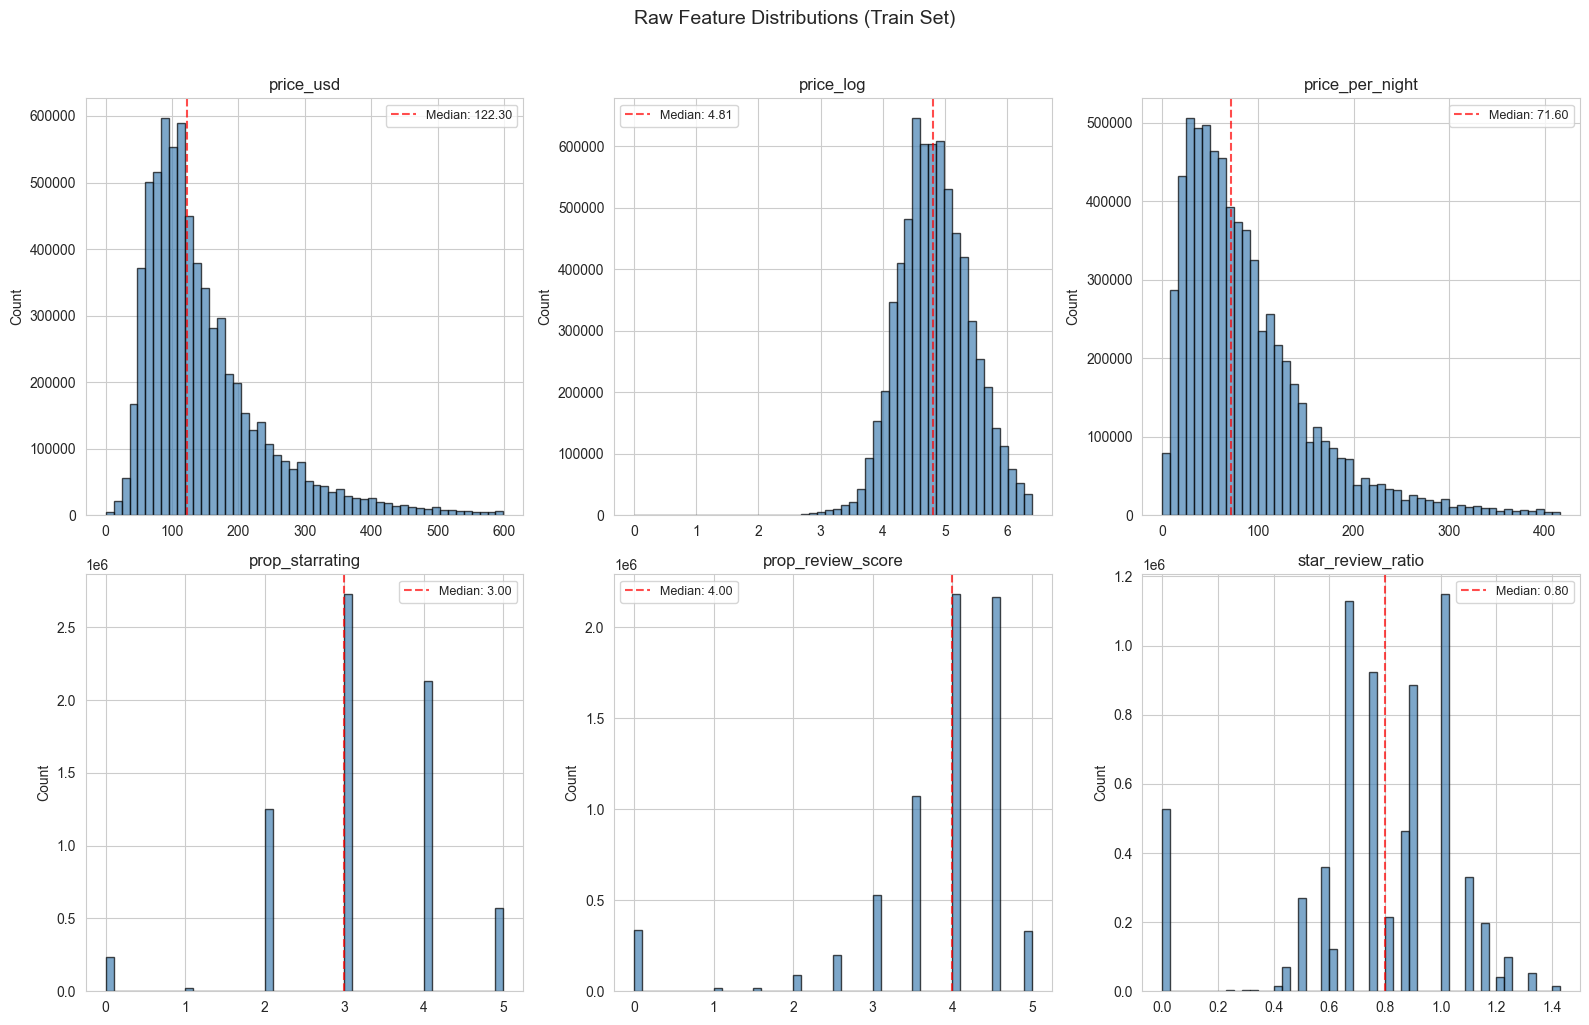

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_cols = ['price_usd', 'price_log', 'price_per_night',
             'prop_starrating', 'prop_review_score', 'star_review_ratio']

for ax, col in zip(axes.ravel(), plot_cols):
    if col in raw_feats.columns:
        data = raw_feats[col].dropna()
        # Clip extreme outliers for visualization
        upper = data.quantile(0.99)
        data_clipped = data[data <= upper]
        ax.hist(data_clipped, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(col, fontsize=12)
        ax.set_ylabel('Count')
        ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7,
                   label=f'Median: {data.median():.2f}')
        ax.legend(fontsize=9)

plt.suptitle('Raw Feature Distributions (Train Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Match Features

Match features capture **query-item interactions** -- how each hotel compares to other hotels *in the same search*. These are critical for LTR because ranking is fundamentally about relative ordering.

### Key features:
- **price_diff_from_query_mean**: `price - mean(prices in this search)`. Negative means cheaper than average.
- **price_ratio_to_query_median**: `price / median(prices)`. Values < 1 indicate below-median pricing.
- **price_zscore_in_query**: Standard-score of price within the query. Normalises for varying price ranges across destinations.
- **star_diff_from_query_mean**: How the star rating compares to the average in this search.
- **star_match_visitor_pref**: `|star_rating - visitor_hist_starrating|`. Small values mean the hotel matches user preferences.
- **location_score_composite**: `0.6 * location_score1 + 0.4 * location_score2`. Weighted blend of two location signals.
- **competitor_rate_advantage**: Count of competitors with a higher rate (= this hotel is cheaper).
- **competitor_inv_advantage**: Count of competitors that are sold out.

In [7]:
from hotel_ranker.features.match_features import build_match_features

match_feats = build_match_features(train_df)

print(f"Match features: {match_feats.shape[1]} columns")
print(f"Columns: {list(match_feats.columns)}")
match_feats.head()

Match features: 10 columns
Columns: ['price_diff_from_query_mean', 'price_ratio_to_query_median', 'price_zscore_in_query', 'star_diff_from_query_mean', 'star_match_visitor_pref', 'location_score_composite', 'competitor_rate_advantage', 'competitor_rate_disadvantage', 'competitor_rate_mean', 'competitor_inv_advantage']


,price_diff_from_query_mean,price_ratio_to_query_median,price_zscore_in_query,star_diff_from_query_mean,star_match_visitor_pref,location_score_composite,competitor_rate_advantage,competitor_rate_disadvantage,competitor_rate_mean,competitor_inv_advantage
0,-58.9489,0.7535,-0.6118,-0.0714,0.0000,1.7155,0,0,0.0000,0
1,7.0211,1.2279,0.0729,0.9286,0.0000,1.3260,0,0,0.0000,1
2,16.0811,1.2931,0.1669,-0.0714,0.0000,1.3298,0,0,0.0000,0
3,439.0511,4.3349,4.5566,-1.0714,0.0000,1.7030,0,3,-0.3750,1
4,-20.1389,1.0326,-0.2090,0.9286,0.0000,1.6336,0,0,0.0000,0


In [8]:
# Summary statistics
match_feats.describe().T

,count,mean,std,min,25%,50%,75%,max
price_diff_from_query_mean,6941198.0000,-0.0000,8910.5615,-2776885.0000,-36.8462,-8.3548,21.8965,16255146.0000
price_ratio_to_query_median,6941198.0000,1.1055,0.9124,0.0000,0.7989,1.0000,1.2480,1000.0000
price_zscore_in_query,6941198.0000,-0.0000,0.9797,-4.9082,-0.6823,-0.1866,0.5223,5.6355
star_diff_from_query_mean,6941198.0000,0.0000,0.8053,-4.8438,-0.4444,0.0312,0.5000,4.7500
star_match_visitor_pref,6941198.0000,0.0414,0.2453,0.0000,0.0000,0.0000,0.0000,5.0000
location_score_composite,6941198.0000,1.7726,0.9442,0.0000,1.0908,1.7126,2.4818,4.5442
competitor_rate_advantage,6941198.0000,0.2333,0.6240,0.0000,0.0000,0.0000,0.0000,6.0000
competitor_rate_disadvantage,6941198.0000,0.1968,0.6115,0.0000,0.0000,0.0000,0.0000,6.0000
competitor_rate_mean,6941198.0000,0.0046,0.1106,-0.7500,0.0000,0.0000,0.0000,0.7500
competitor_inv_advantage,6941198.0000,0.1054,0.3745,0.0000,0.0000,0.0000,0.0000,6.0000


### Visualizing Match Feature Distributions

Match features are centred around zero (for difference-based features) or one (for ratio-based features), which is expected since they measure deviations from query-level statistics.

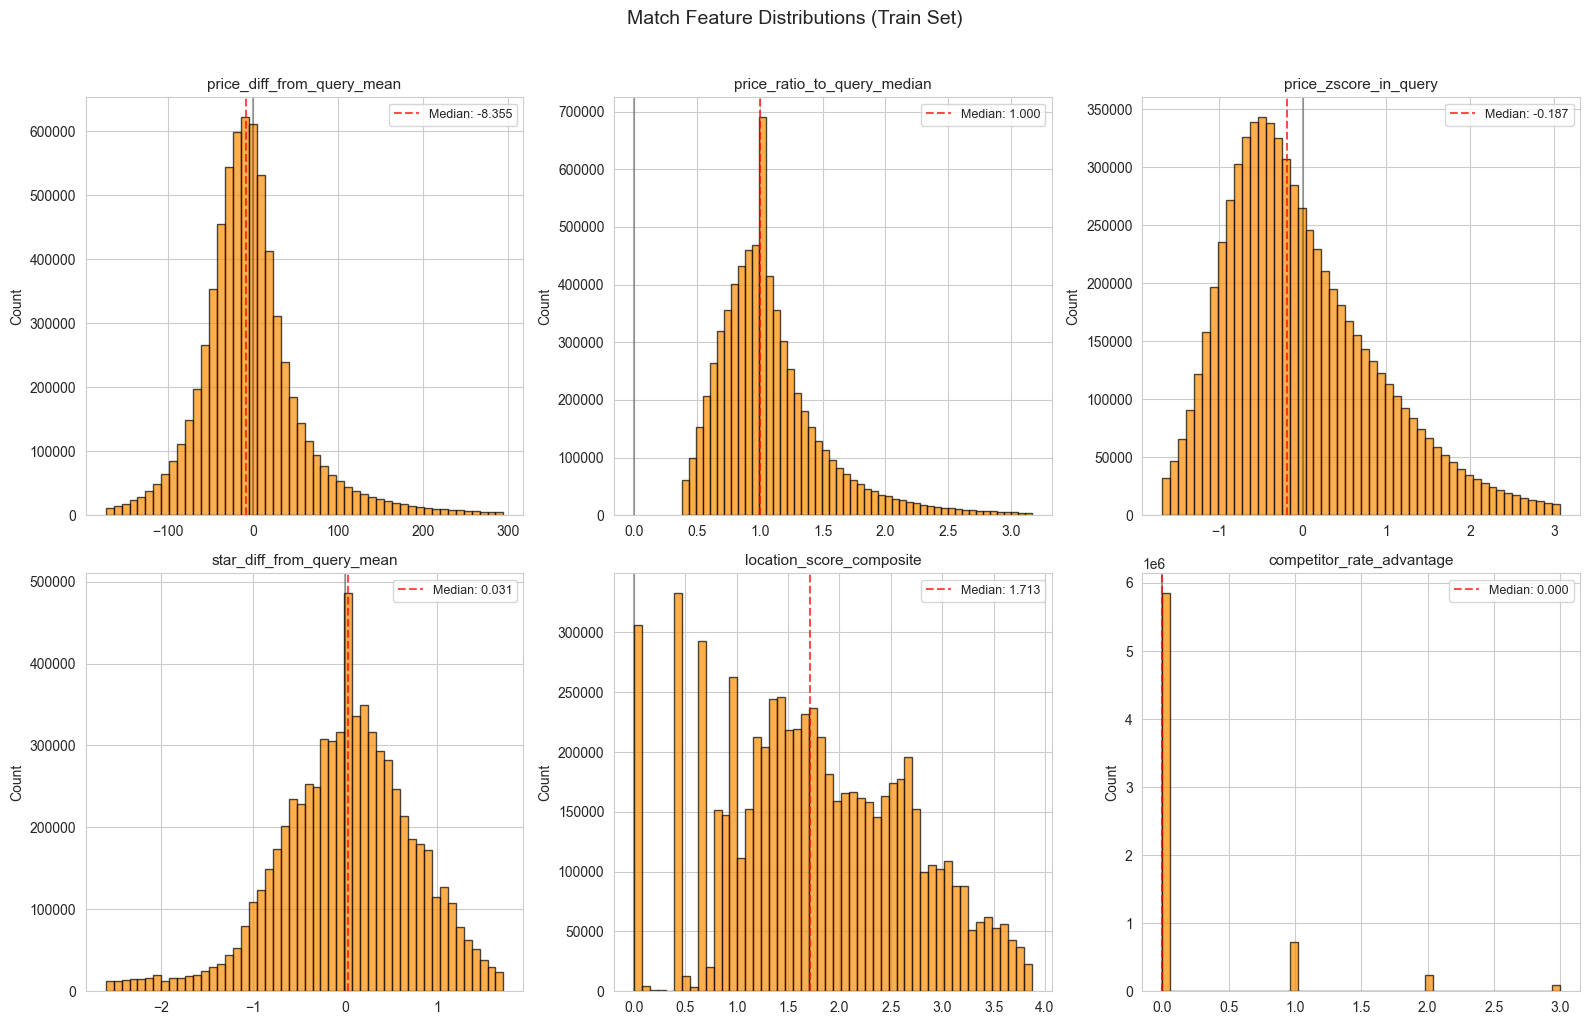

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

match_plot_cols = ['price_diff_from_query_mean', 'price_ratio_to_query_median',
                   'price_zscore_in_query', 'star_diff_from_query_mean',
                   'location_score_composite', 'competitor_rate_advantage']

for ax, col in zip(axes.ravel(), match_plot_cols):
    if col in match_feats.columns:
        data = match_feats[col].dropna()
        lower = data.quantile(0.01)
        upper = data.quantile(0.99)
        data_clipped = data[(data >= lower) & (data <= upper)]
        ax.hist(data_clipped, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
        ax.set_title(col, fontsize=11)
        ax.set_ylabel('Count')
        ax.axvline(0, color='black', linestyle='-', alpha=0.3)
        ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7,
                   label=f'Median: {data.median():.3f}')
        ax.legend(fontsize=9)

plt.suptitle('Match Feature Distributions (Train Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Match Features vs. Click/Booking Behaviour

Let's see if match features correlate with user engagement. We expect items that are cheaper than the query average and better-located to receive more clicks.

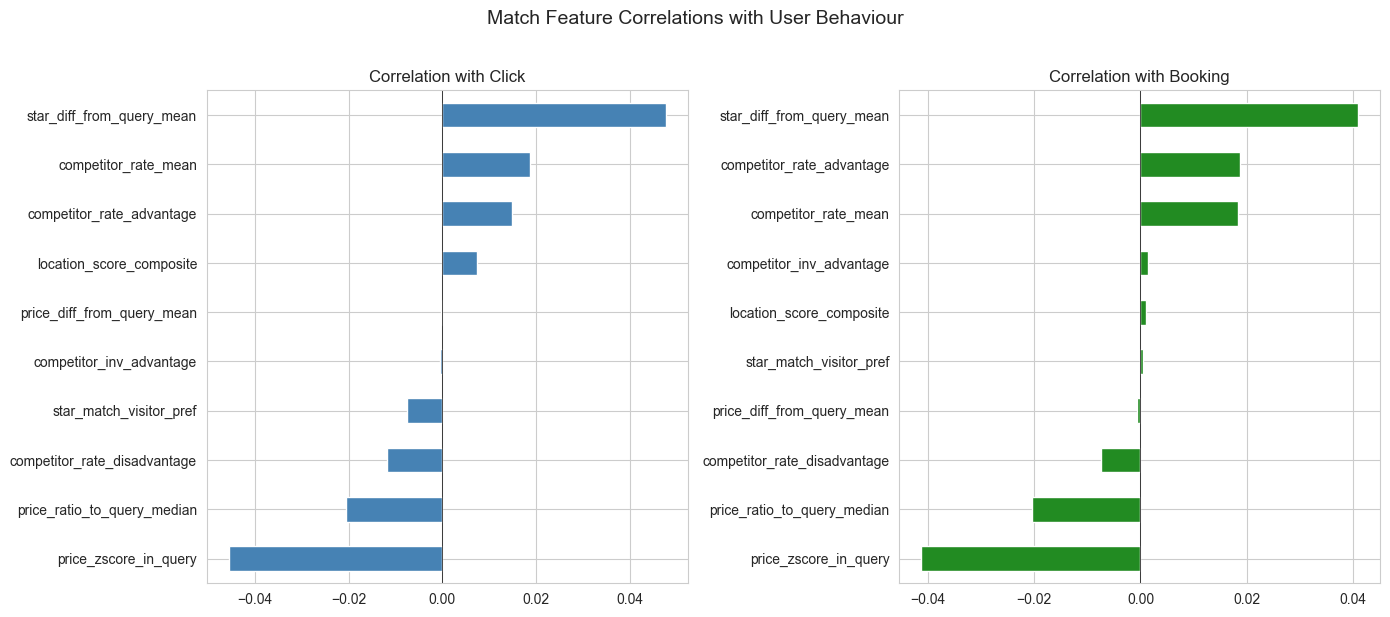

In [10]:
# Combine match features with target columns for analysis
analysis_df = match_feats.copy()
analysis_df['click_bool'] = train_df['click_bool'].values
analysis_df['booking_bool'] = train_df['booking_bool'].values

# Correlation with click and booking
corr_click = analysis_df.corr()['click_bool'].drop(['click_bool', 'booking_bool']).sort_values()
corr_book = analysis_df.corr()['booking_bool'].drop(['click_bool', 'booking_bool']).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_click.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Correlation with Click', fontsize=12)
axes[0].axvline(0, color='black', linewidth=0.5)

corr_book.plot(kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title('Correlation with Booking', fontsize=12)
axes[1].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Match Feature Correlations with User Behaviour', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Historical Features

Historical features encode the *past performance* of properties and destinations. They are typically the most powerful features in ranking systems because they capture real user preferences.

### Bayesian Smoothing
Naively computing `click_rate = clicks / impressions` is unreliable for properties with few impressions (a hotel shown 3 times and clicked 2 has a 67% CTR, which is noise). We use **Bayesian averaging** (shrinkage):

$$\text{smoothed\_rate} = \frac{n \cdot \text{raw\_rate} + C \cdot \text{prior\_rate}}{n + C}$$

where `C = PRIOR_COUNT = 30` is a pseudo-count and `prior_rate = 0.05` is the global baseline CTR. Properties with many impressions converge to their true rate; properties with few impressions shrink toward the global mean.

### Data Leakage Prevention
Historical features are computed **only from the training set** and then merged onto val/test by property ID or destination ID. This ensures the model never sees future clicks during evaluation.

### Features produced:
- **prop_click_rate**: Smoothed click-through rate per property
- **prop_booking_rate**: Smoothed booking rate per property
- **prop_avg_position**: Average display position (popular hotels tend to be shown higher)
- **prop_impression_count**: log1p(total impressions)
- **dest_avg_price**: Average price at the destination
- **dest_avg_star**: Average star rating at the destination
- **dest_booking_rate**: Smoothed booking rate for the destination
- **price_vs_dest_avg**: `price / dest_avg_price` (is this hotel expensive for the area?)

In [11]:
from hotel_ranker.features.historical_features import (
    build_property_history,
    build_destination_history,
    merge_historical_features,
)

# Build historical aggregates from training data ONLY
prop_hist = build_property_history(train_df)
dest_hist = build_destination_history(train_df)

print("=== Property History ===")
print(f"Properties tracked: {len(prop_hist):,}")
print(prop_hist.describe().T)
print()
print("=== Destination History ===")
print(f"Destinations tracked: {len(dest_hist):,}")
print(dest_hist.describe().T)

=== Property History ===
Properties tracked: 133,434
                            count    mean    std    min     25%     50%  \
prop_click_rate       133434.0000  0.0486 0.0235 0.0020  0.0357  0.0446   
prop_booking_rate     133434.0000  0.0414 0.0193 0.0011  0.0300  0.0405   
prop_avg_position     133434.0000 15.7907 6.5005 1.0000 11.2727 16.3333   
prop_impression_count 133434.0000  2.9095 1.4426 0.6931  1.7918  2.7726   

                          75%     max  
prop_click_rate        0.0543  0.3676  
prop_booking_rate      0.0472  0.3135  
prop_avg_position     20.2682 38.0000  
prop_impression_count  4.0073  8.1233  

=== Destination History ===
Destinations tracked: 20,651
                       count     mean        std    min     25%      50%  \
dest_avg_price    20651.0000 353.6384 15401.4658 5.7715 93.9386 116.5317   
dest_avg_star     20651.0000   2.8794     0.7044 0.0000  2.4444   2.8705   
dest_booking_rate 20651.0000   0.0420     0.0166 0.0047  0.0294   0.0397   

        

In [12]:
# Merge historical features onto the training set
hist_feats = merge_historical_features(train_df, prop_hist, dest_hist)

print(f"Historical features: {hist_feats.shape[1]} columns")
print(f"Columns: {list(hist_feats.columns)}")
hist_feats.head()

Historical features: 8 columns
Columns: ['prop_click_rate', 'prop_booking_rate', 'prop_avg_position', 'prop_impression_count', 'dest_avg_price', 'dest_avg_star', 'dest_booking_rate', 'price_vs_dest_avg']


,prop_click_rate,prop_booking_rate,prop_avg_position,prop_impression_count,dest_avg_price,dest_avg_star,dest_booking_rate,price_vs_dest_avg
0,0.0205,0.0127,25.6907,6.7731,155.8090,3.1238,0.0263,0.6724
1,0.0296,0.0212,22.8808,6.6821,155.8090,3.1238,0.0263,1.0958
2,0.0105,0.0080,23.3321,6.6606,155.8090,3.1238,0.0263,1.1540
3,0.0272,0.0140,23.7481,6.4800,155.8090,3.1238,0.0263,3.8686
4,0.0522,0.0408,12.9360,6.8437,155.8090,3.1238,0.0263,0.9215


### Historical Feature Distributions

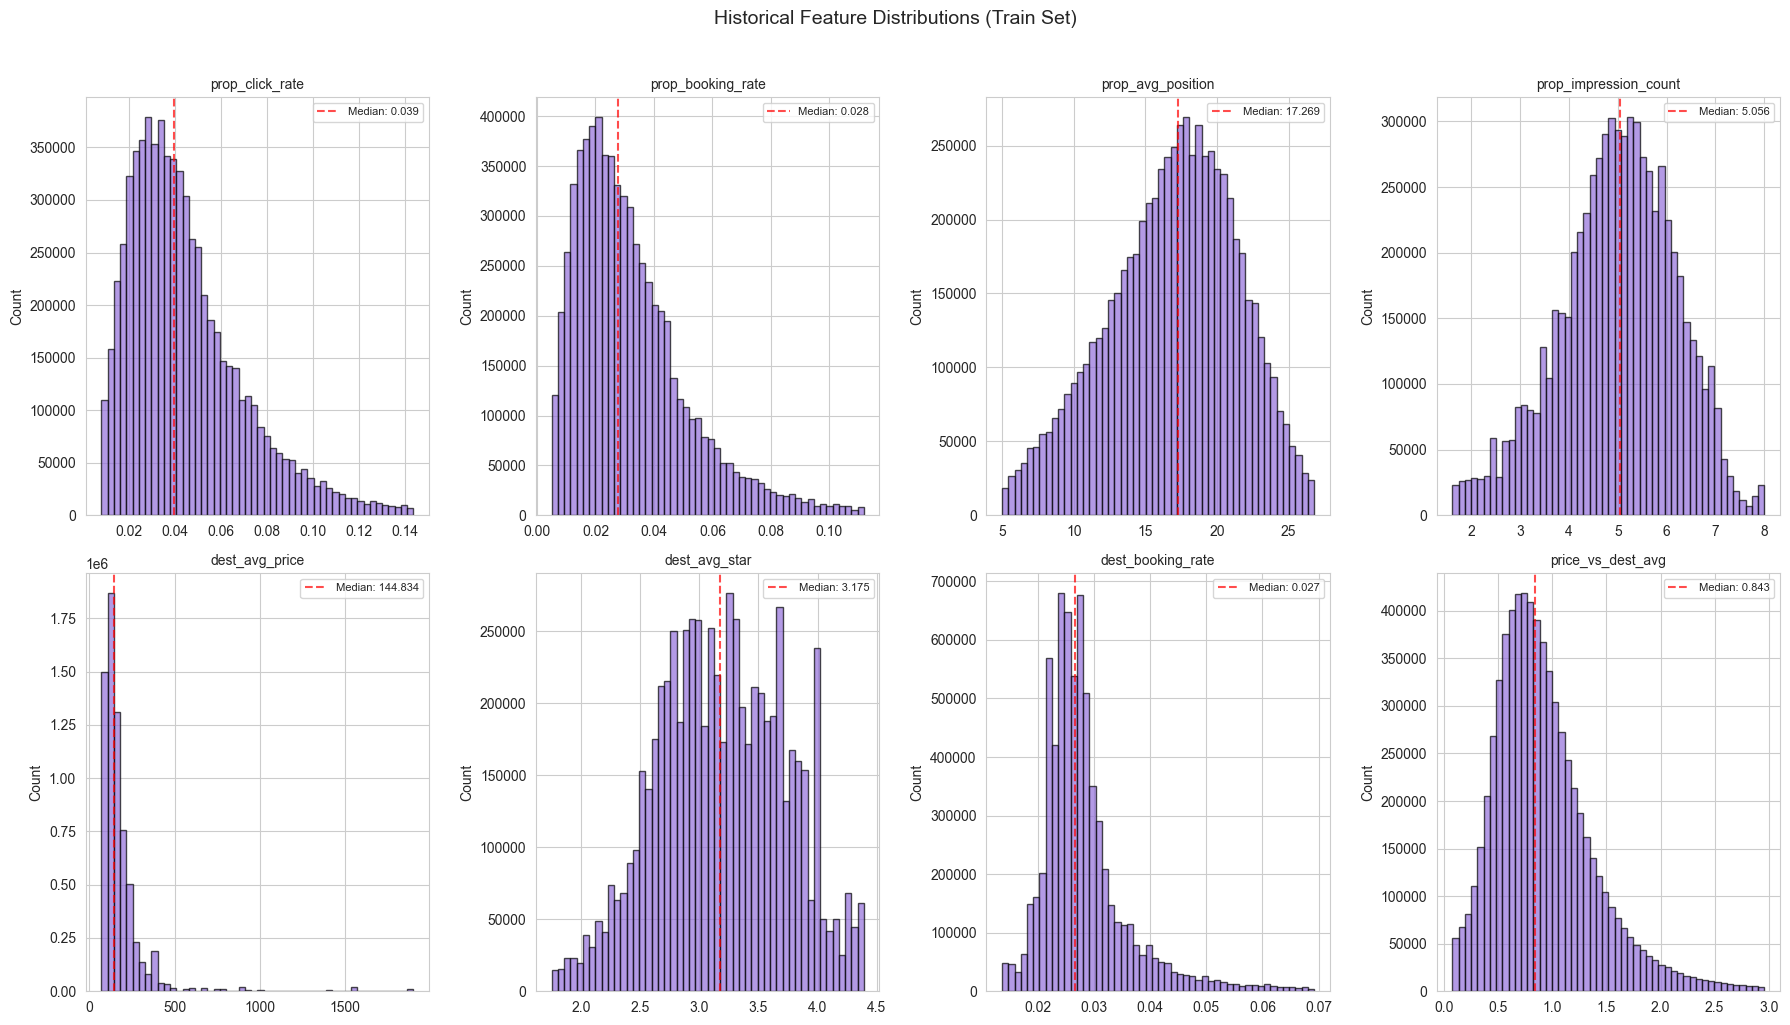

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

hist_plot_cols = list(hist_feats.columns)

for ax, col in zip(axes.ravel(), hist_plot_cols):
    data = hist_feats[col].dropna()
    upper = data.quantile(0.99)
    lower = data.quantile(0.01)
    data_clipped = data[(data >= lower) & (data <= upper)]
    ax.hist(data_clipped, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7,
               label=f'Median: {data.median():.3f}')
    ax.legend(fontsize=8)

# Turn off unused axes if any
for idx in range(len(hist_plot_cols), len(axes.ravel())):
    axes.ravel()[idx].set_visible(False)

plt.suptitle('Historical Feature Distributions (Train Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Bayesian Smoothing Effect

Let's visualize how Bayesian smoothing pulls low-impression properties toward the global prior. Properties with many impressions keep their empirical rates, while properties with few impressions are "shrunk" toward the baseline.

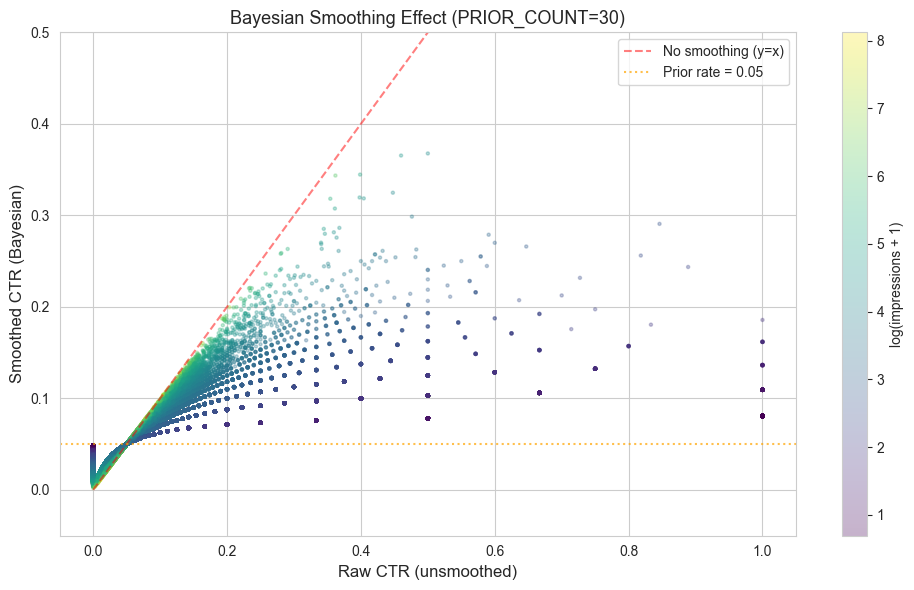

Properties with < 10 impressions: 52,862
Properties with > 100 impressions: 18,602


In [14]:
# Examine the Bayesian smoothing effect
from hotel_ranker.config import PRIOR_COUNT, PRIOR_RATE

# Compute raw (unsmoothed) click rates for comparison
raw_agg = train_df.groupby('prop_id').agg(
    impressions=('click_bool', 'count'),
    clicks=('click_bool', 'sum')
)
raw_agg['raw_ctr'] = raw_agg['clicks'] / raw_agg['impressions'].clip(lower=1)
raw_agg['smoothed_ctr'] = prop_hist['prop_click_rate']
raw_agg['log_impressions'] = np.log1p(raw_agg['impressions'])

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(raw_agg['raw_ctr'], raw_agg['smoothed_ctr'],
                c=raw_agg['log_impressions'], cmap='viridis',
                alpha=0.3, s=5)
plt.colorbar(sc, label='log(impressions + 1)')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='No smoothing (y=x)')
ax.axhline(PRIOR_RATE, color='orange', linestyle=':', alpha=0.7,
           label=f'Prior rate = {PRIOR_RATE}')
ax.set_xlabel('Raw CTR (unsmoothed)', fontsize=12)
ax.set_ylabel('Smoothed CTR (Bayesian)', fontsize=12)
ax.set_title(f'Bayesian Smoothing Effect (PRIOR_COUNT={PRIOR_COUNT})', fontsize=13)
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, max(raw_agg['smoothed_ctr'].max() * 1.1, 0.5))
plt.tight_layout()
plt.show()

print(f"Properties with < 10 impressions: {(raw_agg['impressions'] < 10).sum():,}")
print(f"Properties with > 100 impressions: {(raw_agg['impressions'] > 100).sum():,}")

## 5. Full Feature Pipeline

The `build_features()` function orchestrates all feature generators:
1. Build raw features (per-row transforms)
2. Build match features (within-query interactions)
3. Build historical features (from training data only)
4. Concatenate everything into a single feature matrix

In [15]:
from hotel_ranker.features.feature_pipeline import build_features

# Build full feature set
X_train = build_features(train_df, train_df)
X_val = build_features(val_df, train_df)

print(f"Training features: {X_train.shape}")
print(f"Validation features: {X_val.shape}")
print(f"\nFeature columns ({X_train.shape[1]} total):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

Training features: (6941198, 40)
Validation features: (1487064, 40)

Feature columns (40 total):
   1. prop_starrating
   2. prop_review_score
   3. prop_brand_bool
   4. prop_location_score1
   5. prop_location_score2
   6. prop_log_historical_price
   7. price_usd
   8. promotion_flag
   9. srch_length_of_stay
  10. srch_booking_window
  11. srch_adults_count
  12. srch_children_count
  13. srch_room_count
  14. srch_saturday_night_bool
  15. visitor_hist_starrating
  16. visitor_hist_adr_usd
  17. price_per_night
  18. total_guests
  19. star_review_ratio
  20. price_vs_visitor_hist
  21. price_log
  22. price_rank_in_query
  23. price_diff_from_query_mean
  24. price_ratio_to_query_median
  25. price_zscore_in_query
  26. star_diff_from_query_mean
  27. star_match_visitor_pref
  28. location_score_composite
  29. competitor_rate_advantage
  30. competitor_rate_disadvantage
  31. competitor_rate_mean
  32. competitor_inv_advantage
  33. prop_click_rate
  34. prop_booking_rate
  35. 

In [16]:
# Check for any remaining NaN values
nan_counts = X_train.isna().sum()
if nan_counts.sum() > 0:
    print("Columns with NaN values:")
    print(nan_counts[nan_counts > 0])
else:
    print("No NaN values in the feature matrix -- clean!")

No NaN values in the feature matrix -- clean!


## 6. Feature Correlation Analysis

Let's examine correlations between features. Highly correlated features are not necessarily harmful for tree models (unlike linear models), but understanding correlations helps us reason about what the model might learn.

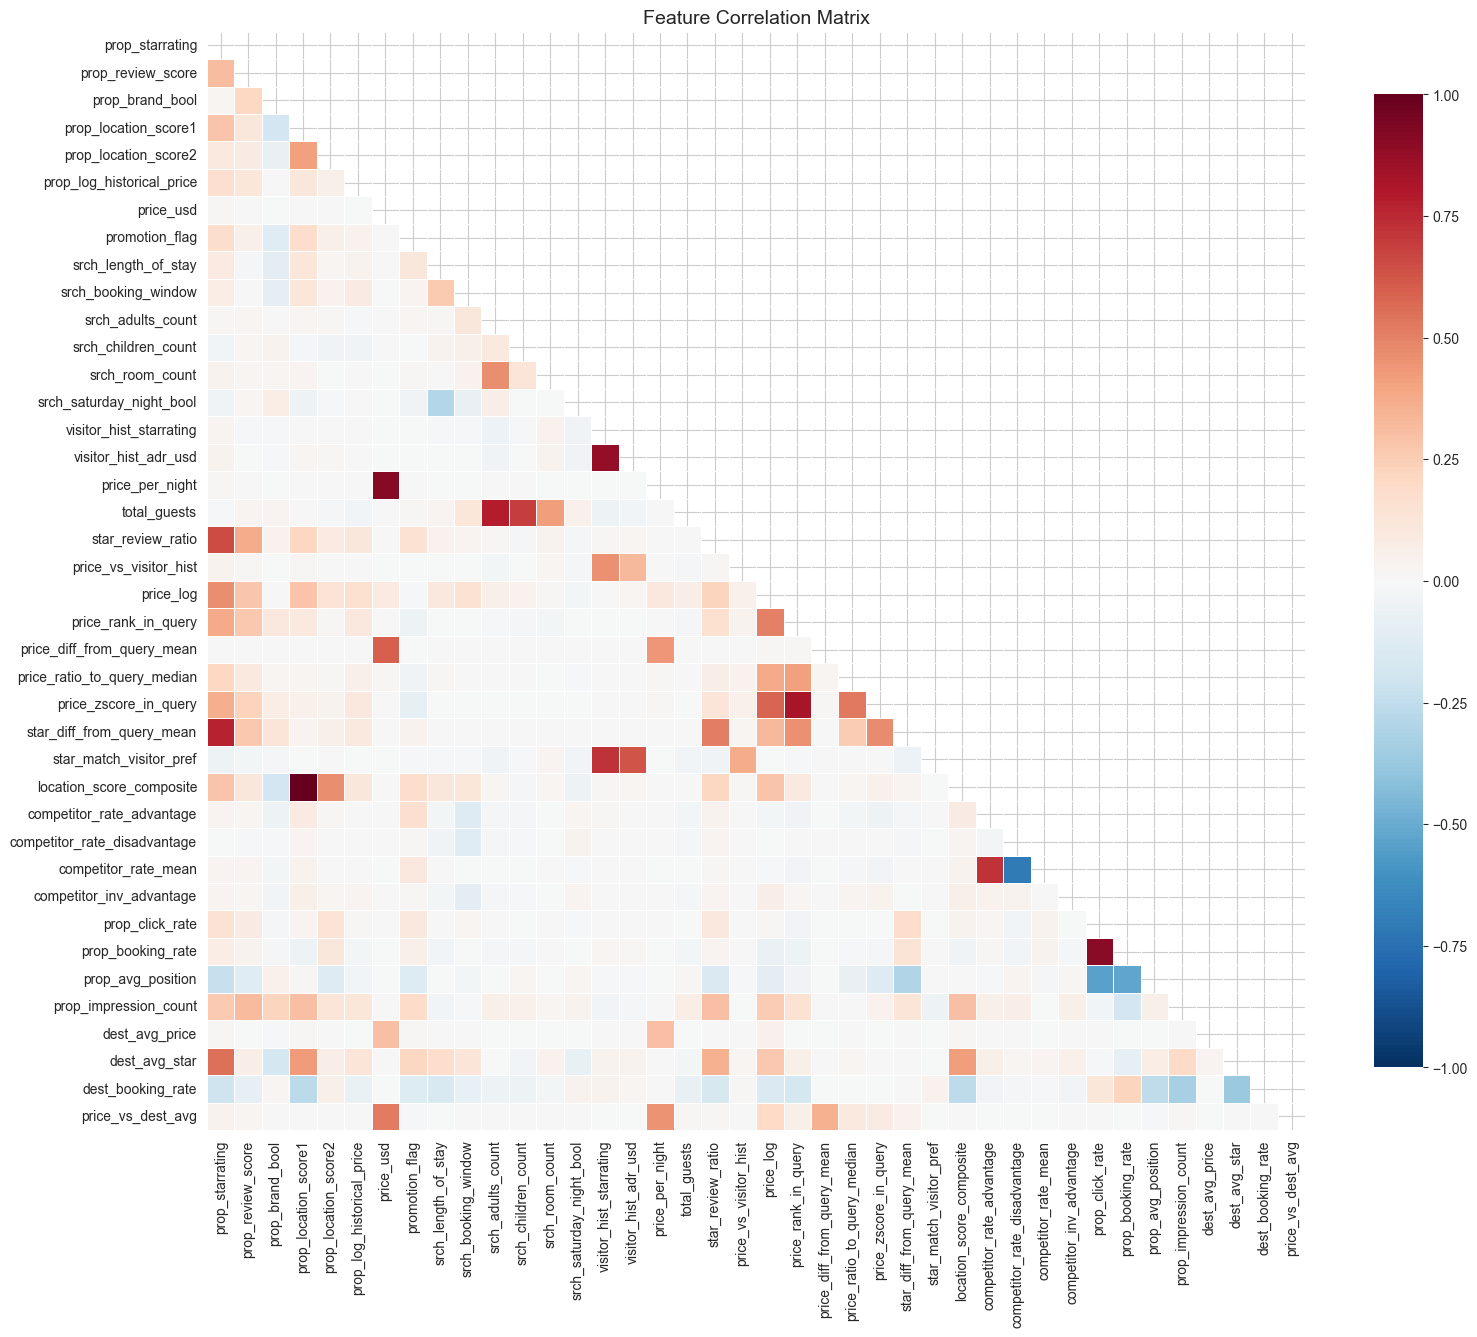

In [17]:
# Compute correlation matrix
corr_matrix = X_train.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Find the most correlated feature pairs (absolute correlation > 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature A', 'Feature B', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False)

print(f"Feature pairs with |correlation| > 0.7: {len(high_corr_df)}")
high_corr_df

Feature pairs with |correlation| > 0.7: 10


,Feature A,Feature B,Correlation
1,prop_location_score1,location_score_composite,0.9985
2,price_usd,price_per_night,0.9067
9,prop_click_rate,prop_booking_rate,0.9027
4,visitor_hist_starrating,visitor_hist_adr_usd,0.8800
6,price_rank_in_query,price_zscore_in_query,0.8274
3,srch_adults_count,total_guests,0.7867
0,prop_starrating,star_diff_from_query_mean,0.7664
7,competitor_rate_advantage,competitor_rate_mean,0.7231
5,visitor_hist_starrating,star_match_visitor_pref,0.7218
8,competitor_rate_disadvantage,competitor_rate_mean,-0.7093


## 7. Feature Summary

Let's create a comprehensive summary of all features: their types, value ranges, and missing value rates.

In [19]:
# Create feature summary table
summary = pd.DataFrame({
    'dtype': X_train.dtypes,
    'mean': X_train.mean(),
    'std': X_train.std(),
    'min': X_train.min(),
    'median': X_train.median(),
    'max': X_train.max(),
    'nan_pct': (X_train.isna().sum() / len(X_train) * 100).round(2),
})

# Classify feature categories
def categorize_feature(name):
    if name.startswith('prop_') or name.startswith('price') or name in ['promotion_flag', 'total_guests', 'star_review_ratio', 'price_vs_visitor_hist']:
        if 'click_rate' in name or 'booking_rate' in name or 'impression' in name or 'avg_position' in name:
            return 'Historical'
        return 'Raw'
    if any(x in name for x in ['query_mean', 'query_median', 'zscore', 'match', 'composite', 'competitor', 'diff_from', 'ratio_to']):
        return 'Match'
    if name.startswith('dest_') or name == 'price_vs_dest_avg':
        return 'Historical'
    return 'Raw'

summary['category'] = [categorize_feature(col) for col in summary.index]
summary = summary[['category', 'dtype', 'mean', 'std', 'min', 'median', 'max', 'nan_pct']]

print(f"Total features: {len(summary)}")
print(f"\nFeatures per category:")
print(summary['category'].value_counts())
print()
summary

Total features: 40

Features per category:
category
Raw           26
Match          7
Historical     7
Name: count, dtype: int64



,category,dtype,mean,std,min,median,max,nan_pct
prop_starrating,Raw,int8,3.1815,1.0508,0.0000,3.0000,5.0000,0.0000
prop_review_score,Raw,float32,3.7720,1.0602,0.0000,4.0000,5.0000,0.0000
prop_brand_bool,Raw,int8,0.6341,0.4817,0.0000,1.0000,1.0000,0.0000
prop_location_score1,Raw,float32,2.8763,1.5318,0.0000,2.7700,6.9800,0.0000
prop_location_score2,Raw,float32,0.1171,0.1434,0.0000,0.0691,1.0000,0.0000
prop_log_historical_price,Raw,float32,4.3198,1.8334,0.0000,4.9100,6.2100,0.0000
price_usd,Raw,float32,243.6265,14982.5332,0.0000,122.3000,19726328.0000,0.0000
promotion_flag,Raw,int8,0.2158,0.4114,0.0000,0.0000,1.0000,0.0000
srch_length_of_stay,Raw,int8,2.3901,2.0665,1.0000,2.0000,59.0000,0.0000
srch_booking_window,Raw,int16,37.6513,52.0148,0.0000,17.0000,498.0000,0.0000


## Key Takeaways

1. **Raw features (passthrough + transforms)** provide the base signal: price, star rating, location, search context. Simple transforms like `price_log` and `price_per_night` help normalise distributions.

2. **Match features** add critical context by measuring each item relative to its query. Features like `price_diff_from_query_mean` and `star_match_visitor_pref` enable the model to understand relative attractiveness.

3. **Historical features** are typically the strongest predictors in production ranking systems. Bayesian smoothing (with `PRIOR_COUNT=30`) prevents overfitting to low-impression items.

4. **Feature leakage prevention** is essential: historical features are computed only from the training set and joined by property/destination ID.

5. The full feature pipeline produces a clean, NaN-free matrix ready for the LGBMRanker. See Notebook 04 for the training workflow.